In [2]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import g_utils
import analysis_utils as a_utils
from interneuron import Interneuron
import sim_utils as s_utils
from neuron import h
import importlib
importlib.reload(g_utils)
h.load_file("stdrun.hoc")
#h.cvode_active(1)

1.0

Current : 0.0nA
[]
Current : 0.001nA
[  10.75        373.825       639.55        932.35       1218.475
 1530.225      1943.1        2191.775      2483.6        2762.72499999
 3082.74999999 3343.17499999 3624.79999998 3882.07499998 4161.92499997
 4464.87499997 4766.09999997 5153.92499996 5467.77499996 5731.29999995
 6009.62499995 6263.74999994 6557.97499994 6812.79999994 7065.17499993
 7364.09999993 7679.97499992 8005.52499992 8262.84999992 8558.12499994
 8907.17499996 9186.49999997 9482.44999999 9836.57500001]
Current : 0.002nA
[  27.35        256.175       465.675       712.6         956.25
 1187.525      1482.775      1707.025      1964.30000001 2234.1
 2610.775      2835.79999999 3080.64999999 3289.99999999 3760.17499998
 3983.62499998 4259.74999997 4482.04999997 4689.97499997 4949.34999996
 5199.92499996 5487.12499996 5763.94999995 5983.07499995 6246.62499994
 6571.64999994 6885.17499993 7106.22499993 7391.64999993 7632.99999992
 7855.87499992 8084.92499992 8360.82499993 8580.99999

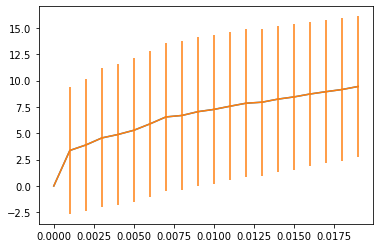

In [8]:
test_interneuron = Interneuron(0)

def f_i_const_curr(curr_amp,time_ms,sigma=50,osc_amp=0):
    
    ic = h.IClamp(test_interneuron.soma(0.5))
    #ic.delay=0
    ic.dur = 1e9
    freq=40
    
    #ic_amp = curr_amp
    T,num_steps = time_ms/1000, time_ms
    time_arr = np.linspace(0,T,num_steps)
    curr_arr = np.full(time_arr.shape,curr_amp)
    theta_arr = osc_amp*np.sin(2*np.pi*freq*time_arr)
    curr_vec = h.Vector(curr_arr+theta_arr)
    
    curr_vec.play(ic, ic._ref_amp, True)
    rec_i = h.Vector().record(ic._ref_amp)
    rec_v = h.Vector().record(test_interneuron.soma(0.5)._ref_v)
    rec_t = h.Vector().record(h._ref_t)
    spike_times = h.Vector()

    nc = h.NetCon(test_interneuron.soma(0.5)._ref_v, None, sec=test_interneuron.soma)
    nc.threshold=0
    nc.record(spike_times)

    h.finitialize(-70)
    h.continuerun(time_ms)

    np_spike_array = np.array(spike_times.to_python())
    print(np_spike_array)
    firing_rate = a_utils.instant_rate(spike_train=spike_times,sim_dur=time_ms,stdev=sigma)*1000 #converting to Hz
    
    del nc,ic,spike_times

    return np.mean(firing_rate), np.std(firing_rate)

    

curr_amp_list = [i*1e-3 for i in range(0,20,1)]
osc_amp = 0.5e-3
freq_mean_list=[]
freq_std_list =[]
for amp in curr_amp_list:
    print(f"Current : {amp}nA")
    mean,std = f_i_const_curr(curr_amp=amp,time_ms=10000,sigma=20,osc_amp=osc_amp)
    freq_mean_list.append(mean)
    freq_std_list.append(std)

plt.plot(curr_amp_list,freq_mean_list)
plt.errorbar(curr_amp_list,freq_mean_list,yerr=freq_std_list)
plt.show()
     


